# Possible paper:

Question: When numerically optimising fermion encodings, 
1. what are the possible metrics? 
    1. Pauli-weight of majorana strings in encoding.
    2. Pauli-weight of majorana strings in encoded fermionic operators.
    3. Pauli-weight of majorana strings in encoded Hamiltonian terms (without coefficients).

    --- Coefficients Needed so enumeration scheme relevant ---

    4. Pauli-weight of majorana strings in non-zero Hamiltonian terms.
    5. Coefficient-scaled Pauli-weight of majorana strings in encoded Hamiltonian terms.

    --- Ansatz / Algorithm Needed ---

    6. Circuit Depth
    7. Two qubit gates

    --- Native gates and topology needed ---

    8. Transpiled Cicruit Depth
    9. Transpiled Two-qubit gates
    8. Energy accuracy

2. How well do these relate to eachother?
3. How well do these predict the quality of the final circuit?

- [ ]

In [1]:
import pickle
from ferrmion.encode import TernaryTree, KNTO
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)

tree = TernaryTree(14)

## 1.1 $P_{HI}$ Hamiltonian Independent

- Take only the mean of the majorana-string lengths

In [2]:
from ferrmion import FermionQubitEncoding
import numpy as np
def hamiltonian_indpendent_weight(encoding: FermionQubitEncoding):
    _, symplectics = encoding._build_symplectic_matrix()
    x_block, z_block = np.hsplit(symplectics, 2)
    operator_weights = np.sum(np.bitwise_or(x_block, z_block),axis=1)
    return operator_weights

In [3]:
ham_indep = {"jw":None,"pe": None,"bk": None,"jkmn": None}
ham_indep["jw"]=hamiltonian_indpendent_weight(tree.JordanWigner())
ham_indep["pe"]=hamiltonian_indpendent_weight(tree.ParityEncoding())
ham_indep["bk"]=hamiltonian_indpendent_weight(tree.BravyiKitaev())
ham_indep["jkmn"]=hamiltonian_indpendent_weight(tree.JKMN())
ham_indep["knto"]=hamiltonian_indpendent_weight(KNTO(14))

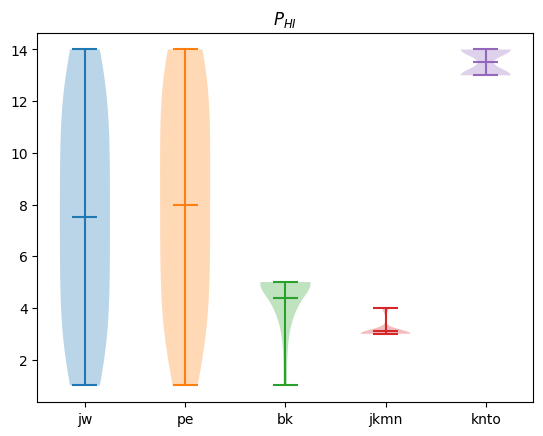

In [4]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots()
pos = 0
for dist in ham_indep.values():
    axs.violinplot(dist, [pos], showmeans=True)
    pos+=1

axs.set_xticks([*range(len(ham_indep))], labels=ham_indep.keys())
plt.title("$P_{HI}$")
plt.show()

## 1.2 Pauli-weight of strings in encoded fermionic operators.

### Edge Operators

In [5]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, KNTO

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "knto":KNTO}
edge_ops = {}
for name, func in encoding_funcs.items():
    encoding = func(14)
    edge_ops[name] = set()
    mode_range = range(encoding.n_modes)
    for i,j in product(mode_range, mode_range):
        paulis = SparsePauliOp.from_sparse_list(encoding.edge_operator((i,j)), num_qubits=encoding.n_modes).simplify().paulis
        edge_ops[name].update([str(p) for p in paulis])

for name, ops in edge_ops.items():
    edge_ops[name] = [len(op)-op.count("I") for op in ops]

<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_53173/3250203947.py:15: SyntaxWarning: invalid escape sequence '\d'
  plt.title("$P_{a^{\dagger}a}$")


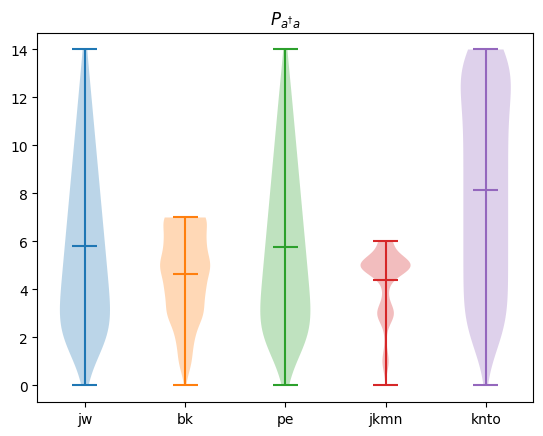

In [6]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots()
pos = 0
for dist in edge_ops.values():
    axs.violinplot(dist, [pos], showmeans=True)
    pos+=1

axs.set_xticks([*range(len(edge_ops))], labels=edge_ops.keys())
plt.title("$P_{a^{\dagger}a}$")
plt.show()

### Exchange Operators

In [7]:
from qiskit.circuit.library import PauliGate
from qiskit.quantum_info import SparsePauliOp
from itertools import product
from ferrmion.encode import JW, BK, ParityEncoding, JKMN, KNTO

encoding_funcs = {"jw":JW, "bk":BK, "pe":ParityEncoding, "jkmn":JKMN, "knto":KNTO}
exchange_ops = {}
for name, func in encoding_funcs.items():
    print(name)
    encoding = func(14)
    exchange_ops[name] = set()
    mode_range = range(encoding.n_modes)
    for i,j in product(mode_range, mode_range):
        lpaulis = SparsePauliOp.from_sparse_list(encoding.edge_operator((i,j)), num_qubits=encoding.n_modes).simplify()
        for k,l in product(mode_range, mode_range):
            rpaulis = SparsePauliOp.from_sparse_list(encoding.edge_operator((k,l)), num_qubits=encoding.n_modes)
            paulis = lpaulis.compose(rpaulis).simplify().paulis
            exchange_ops[name].update([str(p) for p in paulis])

for name, ops in exchange_ops.items():
    exchange_ops[name] = [len(op)-op.count("I") for op in ops]

jw
bk
pe
jkmn
knto


<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:14: SyntaxWarning: invalid escape sequence '\d'
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_53173/781655546.py:13: SyntaxWarning: invalid escape sequence '\d'
  axs[0].title.set_text("$P_{a^{\dagger}a}$")
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_53173/781655546.py:14: SyntaxWarning: invalid escape sequence '\d'
  axs[1].title.set_text("$P_{a^{\dagger}aa^{\dagger}a}$")


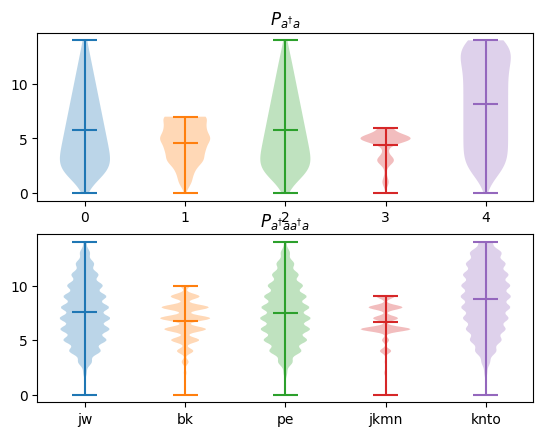

In [8]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots(2,1)
pos = 0
for k in edge_ops.keys():
    axs[0].violinplot(edge_ops[k], [pos], showmeans=True)
    axs[1].violinplot(exchange_ops[k], [pos], showmeans=True)
    pos+=1
axs[0].title.set_text("$P_{a^{\dagger}a}$")
axs[1].title.set_text("$P_{a^{\dagger}aa^{\dagger}a}$")
axs[1].set_xticks([*range(len(edge_ops))], labels=edge_ops.keys())
plt.show()

## 1.3 Pauli-weight of majorana strings in encoded Hamiltonian terms (without coefficients).

This is just the combination of the $a^{\dagger}a$ and $a^{\dagger}aa^{\dagger}a$ terms above

In [9]:
from ferrmion.optimize.enumeration import lambda_plus_mu
from ferrmion.hamiltonians import molecular_hamiltonian_template
from ferrmion.hamiltonians import fill_template
import functools
ones, twos = water_integrals()

templates = {"jw":None,"pe": None,"bk": None,"jkmn": None}

ipowers, symplectics = tree.JW()._build_symplectic_matrix()
templates["jw"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = tree.ParityEncoding()._build_symplectic_matrix()
templates["pe"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = tree.BK()._build_symplectic_matrix()
templates["bk"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = tree.JKMN()._build_symplectic_matrix()
templates["jkmn"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

ipowers, symplectics = KNTO(14)._build_symplectic_matrix()
templates["knto"] = molecular_hamiltonian_template(ipowers, symplectics, physicist_notation=True)

In [10]:
import numpy as np
def template_pauli_weight(template):
    return [len(k) - k.count("I") for k in template.keys()]

ham_dep = {k: template_pauli_weight(v) for k,v in templates.items()}

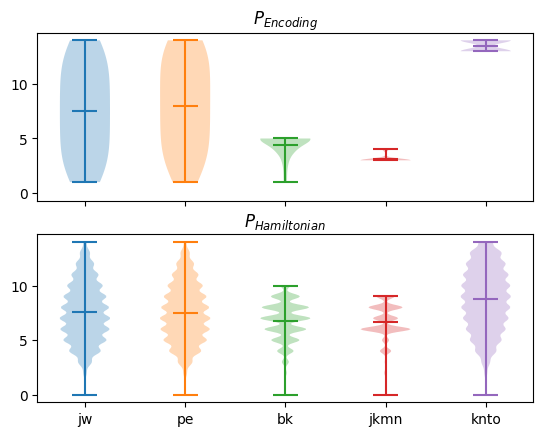

In [11]:
import matplotlib.pyplot as plt

#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots(2,1, sharex=True, sharey=True)
pos = 0
for k in ham_dep.keys():
    axs[0].violinplot(ham_indep[k], [pos], showmeans=True)
    axs[1].violinplot(ham_dep[k], [pos], showmeans=True)
    pos+=1
axs[0].title.set_text("$P_{Encoding}$")
axs[1].title.set_text("$P_{Hamiltonian}$")
axs[1].set_xticks([*range(len(ham_dep))], labels=ham_dep.keys())
plt.show()

In [12]:
def template_pauli_weight(template):
    return np.sum([len(k)-k.count("I") for k in template.keys()])

## 1.4 Pauli-weight of majorana strings in non-zero Hamiltonian terms.
`unscaled` as filled hamiltonian does not contain 0 value terms.

## 1.5 Coefficient-scaled Pauli-weight of majorana strings in encoded Hamiltonian terms.
`scaled`

In [13]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [14]:
def fill_template_find_norms(template, ones, twos, permutation):
    permutation = np.array(permutation, dtype=np.uint)
    ham = fill_template(template, 0, ones, 0.5*twos, permutation)
    
    return pauli_weights(ham)

In [34]:
limit = 100
sdmeans = {}
sdmeans_naive = {}
rng = np.random.RandomState(1017)
for encoding, template in templates.items():
    sdmeans[encoding] = {"unscaled":[], "scaled":[], "length":[]}
    sdmeans_naive[encoding] = {"unscaled":[], "scaled":[], "length":[]}
    
    result = fill_template_find_norms(template, ones, twos, np.array([*range(14)], dtype=np.uint))
    sdmeans_naive[encoding]["unscaled"] = np.mean(result[0])
    sdmeans_naive[encoding]["scaled"] = np.mean(result[1])
    sdmeans_naive[encoding]["length"] = result[2]

    for i in range(100):
        perm = rng.permutation(14)
        result = fill_template_find_norms(template, ones, twos, perm)
        sdmeans[encoding]["unscaled"].append(np.mean(result[0])) 
        sdmeans[encoding]["scaled"].append(np.mean(result[1]))
        sdmeans[encoding]["length"].append(result[2])
        if i >= limit:
            break
        else:
            i+=1
sdmeans

{'jw': {'unscaled': [np.float64(7.101289134438305),
   np.float64(6.751381215469613),
   np.float64(6.808471454880294),
   np.float64(7.110497237569061),
   np.float64(6.620626151012892),
   np.float64(6.931860036832412),
   np.float64(6.972375690607735),
   np.float64(6.5451197053407),
   np.float64(7.088397790055248),
   np.float64(7.147329650092081),
   np.float64(6.394106813996316),
   np.float64(6.933701657458563),
   np.float64(6.567219152854512),
   np.float64(6.900552486187845),
   np.float64(7.031307550644567),
   np.float64(7.186003683241252),
   np.float64(7.081031307550645),
   np.float64(6.863720073664825),
   np.float64(6.786372007366483),
   np.float64(6.565377532228361),
   np.float64(6.902394106813996),
   np.float64(7.025782688766114),
   np.float64(7.10865561694291),
   np.float64(6.863720073664825),
   np.float64(6.65561694290976),
   np.float64(6.650092081031308),
   np.float64(6.998158379373849),
   np.float64(6.723756906077348),
   np.float64(7.10865561694291),
 

! All encodings have the same number of terms in their encoded hamiltonian.

In [35]:
for encoding in sdmeans.keys():
    assert len(set(sdmeans[encoding]["length"]))==1

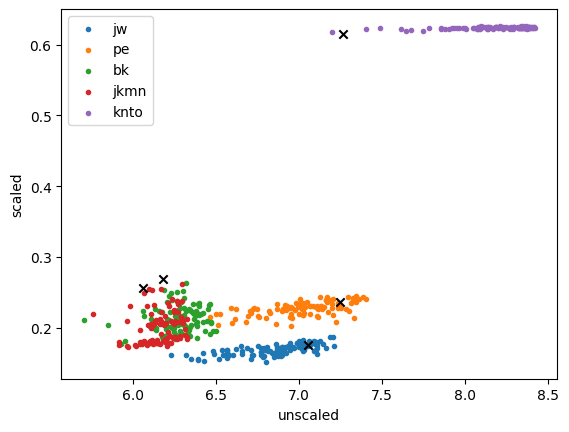

In [36]:
for encoding in sdmeans.keys():
    plt.scatter(sdmeans[encoding]["unscaled"], sdmeans[encoding]["scaled"], label=encoding, marker=".")
    plt.scatter(sdmeans_naive[encoding]["unscaled"], sdmeans_naive[encoding]["scaled"], marker="x", color="black")

plt.xlabel("unscaled")
plt.ylabel("scaled")
plt.legend()

## Simulated Annealing

Enumerations can also be optimised with simulated annealing. 

We just need to provide a temperature (using the number of modes tends to give good results) and an initial permutation.

In [18]:
from ferrmion.core import anneal_enumerations

temp = 14
annealed_best = {}
for encoding in sdmeans.keys():
    annealed_best[encoding] = anneal_enumerations(templates[encoding], ones, 0.5*twos, temp, np.array([*range(14)],dtype=np.uint))

<>:21: SyntaxWarning: invalid escape sequence '\ '
<>:21: SyntaxWarning: invalid escape sequence '\ '
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_53173/2181498423.py:21: SyntaxWarning: invalid escape sequence '\ '
  plt.title("$P_{SD}: H_{2}O\ STO-3G$")


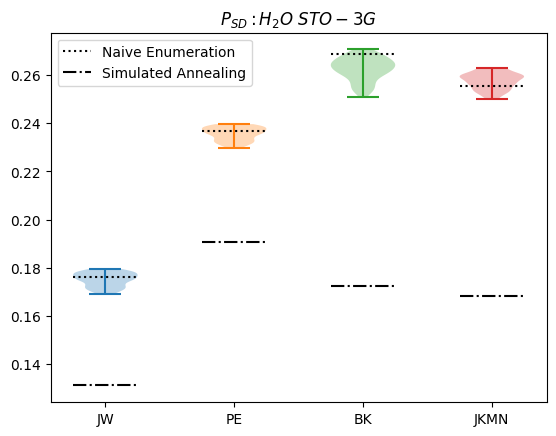

In [29]:
fig, axs = plt.subplots()
pos = 0
for encoding, dist in sdmeans.items():
    n_terms = sdmeans_naive[encoding]["length"]
    if encoding == "knto":
        continue
    dist = dist["scaled"]
    axs.violinplot(dist, [pos])
    pos+=1
axs.set_xticks([*range(len(sdmeans)-1)], labels=["JW", "PE", "BK", "JKMN"])
for pos, encoding in enumerate(sdmeans.keys()):
    if encoding == "knto":
        continue
    axs.hlines(sdmeans_naive[encoding]["scaled"],  pos-0.25, pos+0.25,  linestyles=":", color="black")
    axs.hlines(annealed_best[encoding][0],  pos-0.25, pos+0.25,  linestyles="-.", color="black")

naive_line = mlines.Line2D([], [], color='black', linestyle=":", label="Naive Enumeration")
anneal_line = mlines.Line2D([], [], color='black', linestyle="-.", label="Simulated Annealing")
axs.legend(handles=[naive_line, anneal_line])

plt.title("$P_{SD}: H_{2}O\ STO-3G$")
plt.show()

In [31]:
from ferrmion.core import template_weight_distribution
distributions = {k: template_weight_distribution(templates[k], 0., ones, 0.5*twos, 200) for k in templates.keys()}

<>:20: SyntaxWarning: invalid escape sequence '\ '
<>:20: SyntaxWarning: invalid escape sequence '\ '
/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_53173/3530408833.py:20: SyntaxWarning: invalid escape sequence '\ '
  plt.title("$P_{SD}: H_{2}O\ STO-3G$")


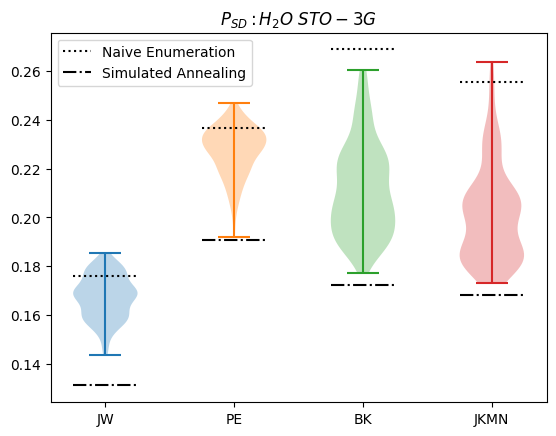

In [32]:
fig, axs = plt.subplots()
pos = 0
for encoding, dist in distributions.items():
    n_terms = sdmeans_naive[encoding]["length"]
    if encoding == "knto":
        continue
    axs.violinplot(dist, [pos])
    pos+=1
axs.set_xticks([*range(len(sdmeans)-1)], labels=["JW", "PE", "BK", "JKMN"])
for pos, encoding in enumerate(sdmeans.keys()):
    if encoding == "knto":
        continue
    axs.hlines(sdmeans_naive[encoding]["scaled"],  pos-0.25, pos+0.25,  linestyles=":", color="black")
    axs.hlines(annealed_best[encoding][0],  pos-0.25, pos+0.25,  linestyles="-.", color="black")

naive_line = mlines.Line2D([], [], color='black', linestyle=":", label="Naive Enumeration")
anneal_line = mlines.Line2D([], [], color='black', linestyle="-.", label="Simulated Annealing")
axs.legend(handles=[naive_line, anneal_line])

plt.title("$P_{SD}: H_{2}O\ STO-3G$")
plt.show()

In [43]:
sdmeans_annealed = {}

for encoding, best in annealed_best.items():
    sdmeans_annealed[encoding] = {"unscaled":[], "scaled":[], "length":[]}
    result = fill_template_find_norms(templates[encoding], ones, twos, best[1])
    sdmeans_annealed[encoding]["unscaled"].append(np.mean(result[0])) 
    sdmeans_annealed[encoding]["scaled"].append(np.mean(result[1]))
    sdmeans_annealed[encoding]["length"].append(result[2])

In [44]:
sdmeans_annealed

{'jw': {'unscaled': [np.float64(5.337016574585635)],
  'scaled': [np.float64(0.1312186302715932)],
  'length': [1086]},
 'pe': {'unscaled': [np.float64(5.79097605893186)],
  'scaled': [np.float64(0.1907371267981504)],
  'length': [1086]},
 'bk': {'unscaled': [np.float64(6.0064456721915285)],
  'scaled': [np.float64(0.1724402256369895)],
  'length': [1086]},
 'jkmn': {'unscaled': [np.float64(6.0451197053407)],
  'scaled': [np.float64(0.16843740240195781)],
  'length': [1086]},
 'knto': {'unscaled': [np.float64(6.232044198895028)],
  'scaled': [np.float64(0.6125649512855815)],
  'length': [1086]}}

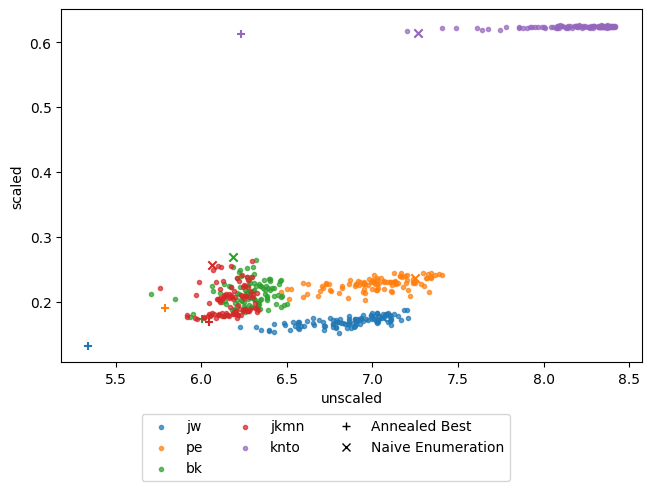

In [93]:
color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red", "knto":"tab:purple"}
fig, ax = plt.subplots(layout="constrained")

for encoding, color in color_set.items():
    ax.scatter(sdmeans[encoding]["unscaled"], sdmeans[encoding]["scaled"], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans_naive[encoding]["unscaled"], sdmeans_naive[encoding]["scaled"], marker="x", color=color)
    ax.scatter(sdmeans_annealed[encoding]["unscaled"], sdmeans_annealed[encoding]["scaled"], marker="+", color=color)


#Imports
import matplotlib.lines as mlines

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
annealed_legend = mlines.Line2D([], [], color='black', label='Annealed Best', marker="+", linestyle="")
naive_legend = mlines.Line2D([], [], color='black', label='Naive Enumeration', marker="x", linestyle="")

# handles is a list, so append manual patch
handles.extend([annealed_legend, naive_legend]) 

ax.set_xlabel("unscaled")
ax.set_ylabel("scaled")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)

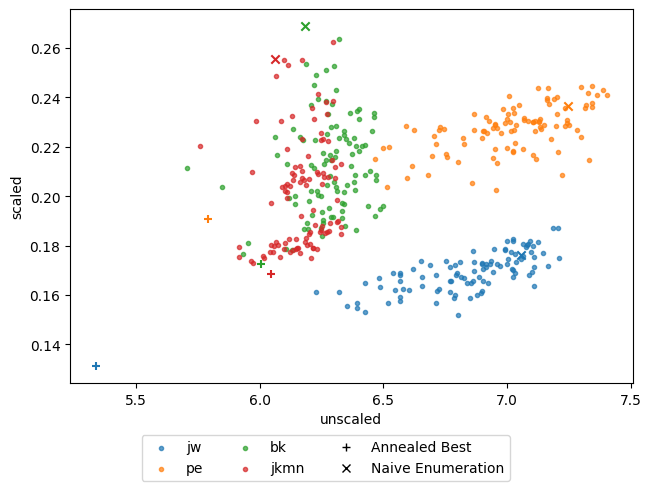

In [94]:
color_set = {"jw":"tab:blue", "pe":"tab:orange", "bk":"tab:green", "jkmn":"tab:red"}
fig, ax = plt.subplots(layout="constrained")

for encoding, color in color_set.items():
    ax.scatter(sdmeans[encoding]["unscaled"], sdmeans[encoding]["scaled"], label=encoding, marker=".", color=color, alpha=0.7)
    ax.scatter(sdmeans_naive[encoding]["unscaled"], sdmeans_naive[encoding]["scaled"], marker="x", color=color)
    ax.scatter(sdmeans_annealed[encoding]["unscaled"], sdmeans_annealed[encoding]["scaled"], marker="+", color=color)


#Imports
import matplotlib.lines as mlines

# where some data has already been plotted to ax
handles, labels = plt.gca().get_legend_handles_labels()

# manually define a new patch 
annealed_legend = mlines.Line2D([], [], color='black', label='Annealed Best', marker="+", linestyle="")
naive_legend = mlines.Line2D([], [], color='black', label='Naive Enumeration', marker="x", linestyle="")

# handles is a list, so append manual patch
handles.extend([annealed_legend, naive_legend]) 

ax.set_xlabel("unscaled")
ax.set_ylabel("scaled")
fig.legend(handles=handles, loc="outside lower center", ncols=len(handles)//2)